# Task 2: Content Type Analysis Dashboard
**Objective:** Analyze the distribution of Movies and TV Shows on Netflix

## Step 1: Load the cleaned dataset
Loaded `netflix_cleaned.csv` produced in Task 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/netflix_cleaned.csv", parse_dates=["date_added"])

print("Shape:", df.shape)
print(df["type"].unique())
df.head()

Shape: (8786, 12)
<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,audience
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,Teens
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,Adults
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,Adults
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,Older Kids
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,Adults


## Step 2: Calculate totals
Counted Movies and TV Shows, with each as a percentage of the catalogue

In [2]:
type_counts = df["type"].value_counts()
type_pct = df["type"].value_counts(normalize=True).mul(100).round(1)

summary = pd.DataFrame({"Count": type_counts, "Percentage (%)": type_pct})
print("Total titles:", len(df))
summary

Total titles: 8786


,Count,Percentage (%)
type,,
Movie,6123,69.7
TV Show,2663,30.3


In [3]:
ratio = type_counts["Movie"] / type_counts["TV Show"]
print(f"There are {ratio:.1f} Movies for every 1 TV Show")

There are 2.3 Movies for every 1 TV Show


## Step 3: Visualize content distribution
Bar chart and donut chart

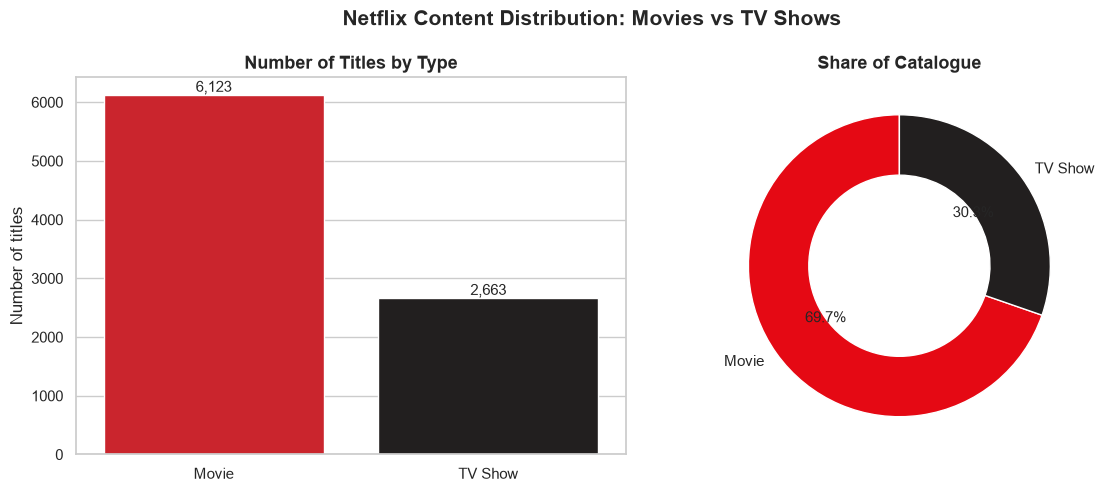

In [4]:
sns.set_theme(style="whitegrid")
colors = {"Movie": "#E50914", "TV Show": "#221F1F"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#bar chart counts
sns.countplot(data=df, x="type", order=type_counts.index,
              palette=colors, hue="type", legend=False, ax=axes[0])
axes[0].set_title("Number of Titles by Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of titles")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)

#donut chart share
axes[1].pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
            colors=[colors[t] for t in type_counts.index], startangle=90,
            wedgeprops={"width": 0.4, "edgecolor": "white"},
            textprops={"fontsize": 11})
axes[1].set_title("Share of Catalogue", fontsize=13, fontweight="bold")

plt.suptitle("Netflix Content Distribution: Movies vs TV Shows", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../screenshots/task2_content_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4: Compare content proportions
Compared the Movie vs TV Show mix within each audience group

In [5]:
#percentage of Movies / TV Shows within each audience group
audience_mix = (pd.crosstab(df["audience"], df["type"], normalize="index") * 100).round(1)
audience_mix["Total titles"] = df["audience"].value_counts()
audience_mix = audience_mix.sort_values("TV Show", ascending=False)
audience_mix

type,Movie,TV Show,Total titles
audience,,,
Kids,48.8,51.2,906
Adults,71.4,28.6,4005
Older Kids,72.0,28.0,1148
Teens,72.4,27.6,2645
Not Rated,95.1,4.9,82


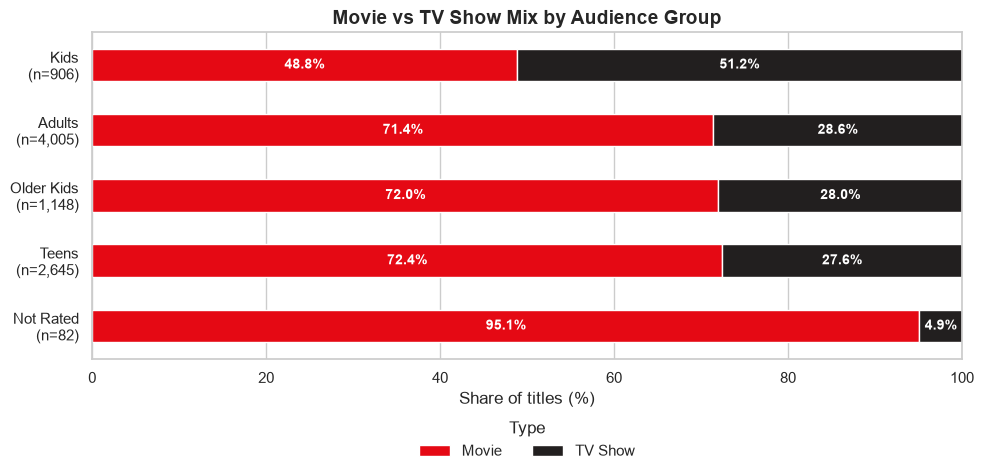

In [6]:
#stacked horizontal bar Movie vs TV Show share per audience group
plot_df = audience_mix.drop(columns="Total titles").sort_values("TV Show")

ax = plot_df.plot(kind="barh", stacked=True, figsize=(10, 5),
                  color=[colors["Movie"], colors["TV Show"]], edgecolor="white")

#label each segment with its percentage
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center",
                 color="white", fontweight="bold", fontsize=10)

#show the group size next to each bar label
ax.set_yticklabels([f"{g}\n(n={audience_mix.loc[g, 'Total titles']:,})" for g in plot_df.index])

ax.set_title("Movie vs TV Show Mix by Audience Group", fontsize=14, fontweight="bold")
ax.set_xlabel("Share of titles (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(title="Type", loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig("../screenshots/task2_audience_mix.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5: Summary of key findings

### Overall distribution
| Type | Titles | Share |
|---|---|---|
| Movie | 6,123 | 69.7% |
| TV Show | 2,663 | 30.3% |

- Netflix's catalogue is **Movie-heavy**: about **2.3 Movies for every 1 TV Show**.
- Total titles analysed: **8,786** (after cleaning in Task 1).

### Mix by audience group
- **Kids is the only group where TV Shows lead** (51.2% TV Shows vs 48.8% Movies).
- Older Kids, Teens and Adults are all close to the overall split, at roughly 71–72% Movies.
- `Not Rated` (95.1% Movies) covers only 82 titles, so this figure is not reliable on its own.

### Business interpretation
- Kids' viewing is built around **series**, which suits repeat viewing and long-running characters. This may explain the heavier TV Show investment in this segment.
- For teen and adult audiences, Netflix relies mainly on **films** to fill the catalogue.
- A possible area for growth is **more TV Show content for teen and adult audiences**, where series make up less than 30% of titles. Series typically encourage longer engagement, but this analysis only shows catalogue mix, not viewing data, so it would need testing against watch-time data.

### Limitations
- Counts show catalogue composition, not viewership or popularity.
- Audience groups are derived from rating labels, so they are approximate.